In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.features import obs_to_dfs

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (500, 2000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E5, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE
noise_density = 0.3
noise_max_val = 1e4

In [9]:
mzml_filename = 'Beer_multibeers_1_fullscan1.mzML'
mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                       min_log_intensity=min_log_intensity,
                                       max_log_intensity=max_log_intensity)

2022-03-21 16:31:24.200 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans
2022-03-21 16:31:26.377 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans


In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
    },
    'noise': {
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol
    }
}

Initialise a new DDA environment that tracks the most intense peaks.

In [56]:
max_peaks = 10
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan) -- can be empty

In [57]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(   intensities  fragmented  excluded  log_intensities
 0          0.0         0.0       0.0              0.0
 1          0.0         0.0       0.0              0.0
 2          0.0         0.0       0.0              0.0
 3          0.0         0.0       0.0              0.0
 4          0.0         0.0       0.0              0.0
 5          0.0         0.0       0.0              0.0
 6          0.0         0.0       0.0              0.0
 7          0.0         0.0       0.0              0.0
 8          0.0         0.0       0.0              0.0
 9          0.0         0.0       0.0              0.0,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start        1.0
 elapsed_scans_since_last_ms1     0.0)

In [58]:
observation['valid_actions']

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [59]:
env.features

[]

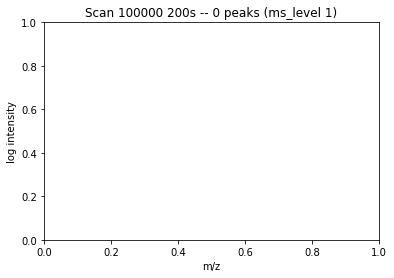

In [60]:
env.render()

Generate 5 ms1 scans

In [61]:
for i in range(5):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(   intensities  fragmented  excluded  log_intensities
 0     0.762237         0.0       0.0        19.055934
 1     0.737595         0.0       0.0        18.439869
 2     0.660415         0.0       0.0        16.510385
 3     0.653394         0.0       0.0        16.334849
 4     0.455310         0.0       0.0        11.382739
 5     0.000000         0.0       0.0         0.000000
 6     0.000000         0.0       0.0         0.000000
 7     0.000000         0.0       0.0         0.000000
 8     0.000000         0.0       0.0         0.000000
 9     0.000000         0.0       0.0         0.000000,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start        6.0
 elapsed_scans_since_last_ms1     0.0)

In [62]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.])

In [63]:
env.features

[mz=131.47707501072793 rt=202.00000000000003 intensity=188750055.16729403 (0.7622373695348168),
 mz=153.80450365667699 rt=202.00000000000003 intensity=101937310.07299381 (0.737594743006906),
 mz=174.84593993650088 rt=202.00000000000003 intensity=14803656.632869659 (0.6604153911202448),
 mz=118.61585185708917 rt=202.00000000000003 intensity=12420382.608114092 (0.6533939775920562),
 mz=118.90935919952564 rt=202.00000000000003 intensity=87793.13063837453 (0.45530954151278047)]

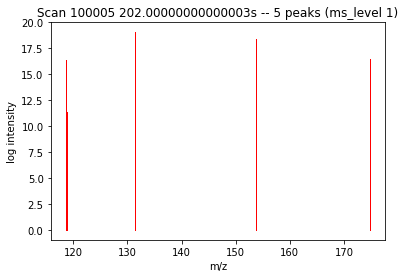

In [64]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [65]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.8491968895351494
done False


(   intensities  fragmented  excluded  log_intensities
 0     0.762237         1.0  0.026667        19.055934
 1     0.737595         0.0  0.000000        18.439869
 2     0.660415         0.0  0.000000        16.510385
 3     0.653394         0.0  0.000000        16.334849
 4     0.455310         0.0  0.000000        11.382739
 5     0.000000         0.0  0.000000         0.000000
 6     0.000000         0.0  0.000000         0.000000
 7     0.000000         0.0  0.000000         0.000000
 8     0.000000         0.0  0.000000         0.000000
 9     0.000000         0.0  0.000000         0.000000,
                               counts
 ms_level                         2.0
 fragmented_count                 1.0
 unfragmented_count               9.0
 excluded_count                   1.0
 unexcluded_count                 9.0
 elapsed_scans_since_start        7.0
 elapsed_scans_since_last_ms1     1.0)

In [66]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.])

In [67]:
env.features

[mz=131.47707501072793 rt=202.00000000000003 intensity=188750055.16729403 (0.7622373695348168),
 mz=153.80450365667699 rt=202.00000000000003 intensity=101937310.07299381 (0.737594743006906),
 mz=174.84593993650088 rt=202.00000000000003 intensity=14803656.632869659 (0.6604153911202448),
 mz=118.61585185708917 rt=202.00000000000003 intensity=12420382.608114092 (0.6533939775920562),
 mz=118.90935919952564 rt=202.00000000000003 intensity=87793.13063837453 (0.45530954151278047)]

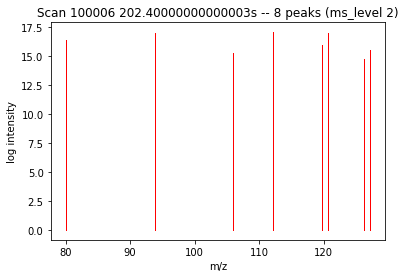

In [68]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [69]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.843071600785073
done False


(   intensities  fragmented  excluded  log_intensities
 0     0.762237         1.0      0.04        19.055934
 1     0.737595         1.0      0.04        18.439869
 2     0.660415         0.0      0.00        16.510385
 3     0.653394         0.0      0.00        16.334849
 4     0.455310         0.0      0.00        11.382739
 5     0.000000         0.0      0.00         0.000000
 6     0.000000         0.0      0.00         0.000000
 7     0.000000         0.0      0.00         0.000000
 8     0.000000         0.0      0.00         0.000000
 9     0.000000         0.0      0.00         0.000000,
                               counts
 ms_level                         2.0
 fragmented_count                 2.0
 unfragmented_count               8.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start        8.0
 elapsed_scans_since_last_ms1     2.0)

In [70]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.])

In [71]:
env.features

[mz=131.47707501072793 rt=202.00000000000003 intensity=188750055.16729403 (0.7622373695348168),
 mz=153.80450365667699 rt=202.00000000000003 intensity=101937310.07299381 (0.737594743006906),
 mz=174.84593993650088 rt=202.00000000000003 intensity=14803656.632869659 (0.6604153911202448),
 mz=118.61585185708917 rt=202.00000000000003 intensity=12420382.608114092 (0.6533939775920562),
 mz=118.90935919952564 rt=202.00000000000003 intensity=87793.13063837453 (0.45530954151278047)]

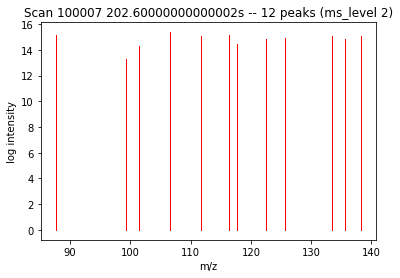

In [72]:
env.render()

Repeat targeting of the same precursor produces negative reward, up to a point

In [73]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward -0.1
reward -0.1
reward -0.1
reward -0.1
reward -0.1
reward -0.1
reward -0.1
reward -0.1
reward -0.1
reward -0.1


In [74]:
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(   intensities  fragmented  excluded  log_intensities
 0     0.762237        11.0  0.173333        19.055934
 1     0.737595         1.0  0.173333        18.439869
 2     0.660415         0.0  0.000000        16.510385
 3     0.653394         0.0  0.000000        16.334849
 4     0.455310         0.0  0.000000        11.382739
 5     0.000000         0.0  0.000000         0.000000
 6     0.000000         0.0  0.000000         0.000000
 7     0.000000         0.0  0.000000         0.000000
 8     0.000000         0.0  0.000000         0.000000
 9     0.000000         0.0  0.000000         0.000000,
                               counts
 ms_level                         2.0
 fragmented_count                 2.0
 unfragmented_count               8.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start       18.0
 elapsed_scans_since_last_ms1    12.0)

In [75]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.])

In [76]:
env.features

[mz=131.47707501072793 rt=202.00000000000003 intensity=188750055.16729403 (0.7622373695348168),
 mz=153.80450365667699 rt=202.00000000000003 intensity=101937310.07299381 (0.737594743006906),
 mz=174.84593993650088 rt=202.00000000000003 intensity=14803656.632869659 (0.6604153911202448),
 mz=118.61585185708917 rt=202.00000000000003 intensity=12420382.608114092 (0.6533939775920562),
 mz=118.90935919952564 rt=202.00000000000003 intensity=87793.13063837453 (0.45530954151278047)]

Making an invalid move produces negative reward.

In [77]:
action = 9 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -1.0
done False


(   intensities  fragmented  excluded  log_intensities
 0     0.762237        11.0  0.186667        19.055934
 1     0.737595         1.0  0.186667        18.439869
 2     0.660415         0.0  0.000000        16.510385
 3     0.653394         0.0  0.000000        16.334849
 4     0.455310         0.0  0.000000        11.382739
 5     0.000000         0.0  0.000000         0.000000
 6     0.000000         0.0  0.000000         0.000000
 7     0.000000         0.0  0.000000         0.000000
 8     0.000000         0.0  0.000000         0.000000
 9     0.000000         1.0  0.000000         0.000000,
                               counts
 ms_level                         2.0
 fragmented_count                 3.0
 unfragmented_count               7.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start       19.0
 elapsed_scans_since_last_ms1    13.0)

In [78]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.])

In [79]:
env.features

[mz=131.47707501072793 rt=202.00000000000003 intensity=188750055.16729403 (0.7622373695348168),
 mz=153.80450365667699 rt=202.00000000000003 intensity=101937310.07299381 (0.737594743006906),
 mz=174.84593993650088 rt=202.00000000000003 intensity=14803656.632869659 (0.6604153911202448),
 mz=118.61585185708917 rt=202.00000000000003 intensity=12420382.608114092 (0.6533939775920562),
 mz=118.90935919952564 rt=202.00000000000003 intensity=87793.13063837453 (0.45530954151278047)]

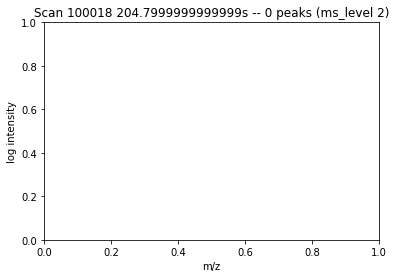

In [80]:
env.render()

Generate lots of MS1 scans

In [81]:
for i in range(100):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(   intensities  fragmented  excluded  log_intensities
 0     0.894985         0.0       0.0        22.374623
 1     0.880734         0.0       0.0        22.018340
 2     0.851552         0.0       0.0        21.288791
 3     0.838559         0.0       0.0        20.963986
 4     0.836848         0.0       0.0        20.921189
 5     0.827743         0.0       0.0        20.693570
 6     0.822790         0.0       0.0        20.569742
 7     0.811477         0.0       0.0        20.286919
 8     0.809975         0.0       0.0        20.249378
 9     0.809285         0.0       0.0        20.232129,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start      119.0
 elapsed_scans_since_last_ms1     0.0)

In [82]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [83]:
env.features

[mz=268.54704750965317 rt=244.60000000000045 intensity=5214049005.1663 (0.8949849020471851),
 mz=229.65241140092286 rt=244.60000000000045 intensity=3651265735.9585776 (0.8807335888561011),
 mz=116.56869959795318 rt=244.60000000000045 intensity=1760371163.1071935 (0.8515516204756713),
 mz=374.0713528702385 rt=244.60000000000045 intensity=1272164591.820961 (0.838559427583162),
 mz=118.24941970216993 rt=244.60000000000045 intensity=1218868872.2501922 (0.8368475644690108),
 mz=360.80852270915915 rt=244.60000000000045 intensity=970740309.4845449 (0.8277427817609015),
 mz=248.23792330211307 rt=244.60000000000045 intensity=857680101.1976405 (0.8227896698200889),
 mz=153.80450365667699 rt=244.60000000000045 intensity=646393491.6251905 (0.8114767598588528),
 mz=190.18981301571765 rt=244.60000000000045 intensity=622576864.7562463 (0.8099751062480196),
 mz=118.21014068109399 rt=244.60000000000045 intensity=611930279.1003115 (0.8092851564379268)]

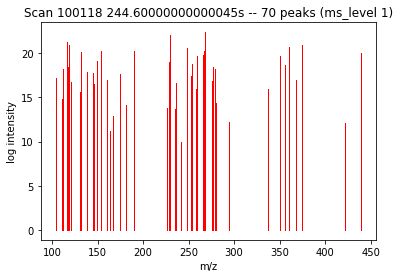

In [84]:
env.render()